# V768 - Measuring Vision with Psychophysics

## Lab 2 - Signal Detection Theory

**How well can a person distinguish between information and noise?** In this lab, you will learn about signal detection theory (SDT), which gives us a framework that we can use to answer that question.

As a primer, recall the method of constant stimuli experiment from last week's lab. In most trials, a grating (signal) was present, but in some, the grating was set to have the same luminance as the background. Likewise, you probably reported seeing (detecting) a grating in most trials but reported not seeing a grating in some. We could use that information to divide those trials into four groups:

| | Detected | Not Detected |
|---|---|---|
| Signal Present | HIT | MISS |
| Signal Absent | FALSE ALARM | CORRECT REJECTION |

By the end of this tutorial, you will understand how classifying responses as hits, misses, false alarms, and correct rejections allows you to calculate the detectability of a particular stimulus for an observer.

*Based on [work](https://gru.stanford.edu/doku.php/tutorials/sdt) by Justin Gardner, Stanford University.*

### Learning Outcomes

By the end of this lab, you will be able to:

1. Define and calculate hits, misses, false alarms, and correct rejections.
2. Explain the role of the criterion in determining the number of hits, misses, false alarms, and correct rejections.
3. Calculate d-prime. Describe how this measure of sensitivity can be independent of the decision criterion of the observer.

### Questions

**A. Simulate a Signal Detection Experiment**

1. In your own words, explain the x-axis of signal detection distributions.

**B. Analyze Simulated Data**

1. What are the two ways to be "right" in a signal detection experiment?
2. Include and write a figure caption for the 3-panel figure in Part B, Step 1.
3. Report the results from Part B (hits, misses, false alarms, and correct rejections) in table form, and write a description of the results, including an explanation of the significance of each number.

**C. Test the Impact of the Criterion Value**

1. Include and write a figure caption for the figure in Part C, Step 1.
2. Include and write figure captions for the two figures in Part C, Step 2.
3. Describe how changing the observer's decision criterion affects the observer's performance.
4. Do you think that there is a relationship between the observer's decision criterion and d'? Why, or why not?

**D. Test the Impact of d'**

1. Include and write a figure caption for the figure in Part D, Step 1.
2. Include and write a figure caption for the figure in Part D, Step 2.
3. Describe how changing the observer's d' affects the observer's performance.

**E. Wrap-Up**

1. Describe the process of simulating an experiment, and discuss what we can learn from simulations.

## Part A. Simulate a Signal Detection Experiment

A useful approach to better understanding any decision model, experimental method, or analysis tool is building a simulation. Simulations allow you to control and play around with the variables involved to see what effect any particular change has. Therefore, today we are going to simulate a signal detection experiment. For convenience, let's call our simulated observer Turtle.

In [55]:
#                              ___-------___
#                          _-~~             ~~-_
#                       _-~                    /~-_
#    /^\__/^\         /~  \                   /    \
#  /|  O|| O|        /      \_______________/        \
# | |___||__|      /       /                \          \
# |          \    /      /                    \          \
# |   (_______) /______/                        \_________ \
# |         / /         \                      /            \
#  \         \^\\         \                  /               \     /
#    \         ||           \______________/      _-_       //\__//
#      \       ||------_-~~-_ ------------- \ --/~   ~\    || __/
#        ~-----||====/~     |==================|       |/~~~~~
#         (_(__/  ./     /                    \_\      \.
#                (_(___/                         \_____)_)

**What is a signal detection experiment?**

Any task that requires an observer to try to detect the presence of a signal. For example, can you see if a candle is lit in a window from 1 mile away? Can you see a friend's face within a crowd?

Sometimes these experiments are called "Yes / No" experiments since the observer has to say either "Yes" they saw it or "No" they did not. In these experiments, the signal is present in some trials (signal-present trials) and absent in others (signal-absent trials).

### Step 0. Prerequisite Modules and Packages

Run the code cell below to load the necessary libraries for this lab. This notebook uses `re`, `numpy`, `matplotlib`, `pandas`, and `seaborn` for data handling and graphing. It also includes a small `python-psignifit` helper so any psychometric-function fits in this course use `psignifit`, not ad hoc curve fitting.

The current signal-detection simulation does not fit a psychometric function, but the helper is ready for datasets that do.

In [56]:
from pathlib import Path
from statistics import NormalDist
import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    import psignifit as ps
    import psignifit.psigniplot as psp
except ImportError:
    ps = None
    psp = None
    print("python-psignifit is not installed. Install it with: pip install psignifit")

sns.set_theme(style="white", context="notebook")
rng = np.random.default_rng(42)
normal = NormalDist()

def fit_psychometric_function(data, experiment_type="2AFC", sigmoid="gauss", **kwargs):
    """Fit a psychometric function with python-psignifit.

    Parameters
    ----------
    data : array-like, shape (n, 3)
        Columns are stimulus level, number correct/yes, and number of trials.
    experiment_type : str
        psignifit experiment type, such as "2AFC" or "yes/no".
    sigmoid : str
        psignifit sigmoid, such as "gauss" or "logistic".
    """
    if ps is None:
        raise ImportError("Install python-psignifit with `pip install psignifit` to fit psychometric functions.")
    return ps.psignifit(data, experiment_type=experiment_type, sigmoid=sigmoid, **kwargs)

### Step 1. Build a Set of Trials

First, we need to create a set of trials. We want half of them to be **signal-present** and half to be **signal-absent** (i.e., noise), but we also want to randomize the order of trials.

In [57]:
# How many trials should we simulate?
n_trials = 5000

# Make half of the trials signal-present (True) and half signal-absent (False).
trial_type = np.zeros(n_trials, dtype=bool)
trial_type[: n_trials // 2] = True

# Shuffle the order of trials.
trial_type = rng.permutation(trial_type)

#### Check Trial Counts

When building a simulation, it is always good to double check the results of your programming to make sure that things worked out the way you expected.

In [58]:
n_present = np.sum(trial_type)
n_absent = np.sum(~trial_type)

print(f"number of signal-present trials: {n_present}")
print(f"number of signal-absent trials:  {n_absent}")

number of signal-present trials: 2500
number of signal-absent trials:  2500


### Step 2. Simulate Observer's Perception

#### The Scale of Signal Perception

Think back to the method of constant stimuli experiment from last week's lab. During each trial, you had to decide whether or not you saw a grating. Your level of confidence that a signal was present likely varied quite a bit, certainly **across** the levels of contrast but potentially even **within** each contrast level. For each trial, imagine plotting your level of confidence along a number line, like so:

<img src="./photos/sdt-number-line.png" alt="signal detection number line" width="500" style="display:block; margin-left:auto; margin-right:auto;">

If you repeat that exercise for multiple trials at the same contrast level, you can plot the distribution of your confidence levels:

<img src="./photos/sdt-histogram.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">


Think of these plots as visual representations of **internal signal strength**. In other words, we aren't plotting the ***<u>actual</u>*** strength of the stimulus, rather we're plotting how visible (or invisible) the stimulus was to ***<u>you</u>***. Moreover, we're plotting the ***variability*** of your perception of the stimulus's strength. When shown the same stimulus over and over, neurons won't always respond the same amount. Likewise, you won't always perceive a particular stimulus the same way each time that you see it. (That's one reason why we include multiple repeats of trials in experiments!) This variability is due to your visual system's **internal noise**.

#### Simulating distributions of percepts

To account for the presence of this internal noise, we want to simulate our observer Turtle's internal signal strength per trial. We can then use their internal signal strength to determine their choice per trial.
<br><br>
Let's assume that Turtle's perception of signal-present trials follows one Gaussian (i.e., normal) distribution and that Turtle's perception of signal-absent trials follows a different, independent Gaussian distribution. Further, let's assume that those two distributions have ***different means*** but the ***same*** standard deviation. In other words, let's assume that Turtle's two sets of internal signal strengths are **independent and identically distributed (IID)**.

In [59]:
dist_stdev = 1
dist_mean_present = 1
dist_mean_absent = -1

internal_signal = np.empty(n_trials)
internal_signal[trial_type] = rng.normal(dist_mean_present, dist_stdev, size=n_present)
internal_signal[~trial_type] = rng.normal(dist_mean_absent, dist_stdev, size=n_absent)

#### Check Simulated Distributions

To make sure that our simulation is working as expected, we can numerically confirm that the means and standard deviations of the signal-present and signal-absent distributions are what they should be.

In [60]:
distribution_summary = pd.DataFrame(
    {
        "mean": [internal_signal[trial_type].mean(), internal_signal[~trial_type].mean()],
        "stdev": [internal_signal[trial_type].std(ddof=1), internal_signal[~trial_type].std(ddof=1)],
    },
    index=["signal-present", "signal-absent"],
)
distribution_summary

,mean,stdev
signal-present,0.999107,1.009378
signal-absent,-0.996517,0.989931


These numbers should be close to the means and standard deviations that we selected, but they likely will not exactly match them. This is because we randomly selected numbers from the distributions to better simulate the randomness and variability of a real observer's perception during an experiment.

#### Plot Simulated Distributions of Internal Signal Strength

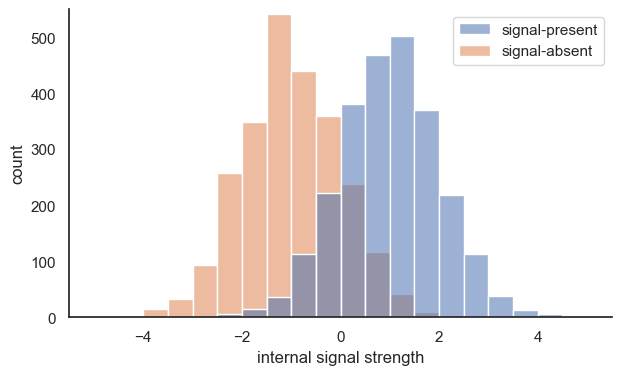

In [61]:
histogram_bins = np.arange(-5, 5.5, 0.5)
plot_df = pd.DataFrame({
    "internal_signal": internal_signal,
    "trial_type": np.where(trial_type, "signal-present", "signal-absent"),
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=plot_df,
    x="internal_signal",
    hue="trial_type",
    bins=histogram_bins,
    multiple="layer",
    alpha=0.55,
    edgecolor="white",
    ax=ax,
)
ax.set(xlabel="internal signal strength", ylabel="count")
sns.despine(ax=ax)

ax.get_legend().set_title('')	

counts_present, _ = np.histogram(internal_signal[trial_type], bins=histogram_bins)
counts_absent, _ = np.histogram(internal_signal[~trial_type], bins=histogram_bins)
histogram_max = int(np.ceil(max(counts_present.max(), counts_absent.max()) / 10) * 10)
ax.set_ylim(0, histogram_max);

### Step 3. Simulate Observer's Decision-Making

Now that we know Turtle's internal signal strength per trial, we need to determine which of the two alternatives ("Yes" vs. "No") Turtle would choose per trial. To make that determination, we need to define Turtle's **decision criterion**. A decision criterion is the internal signal strength threshold an observer uses to decide between two alternatives.

Turtle's criterion could fall anywhere along the scale from "definitely no" to "definitely yes", but for now, let's place Turtle's criterion exactly in the middle of the means of our two distributions.

In [62]:
criterion = np.mean([dist_mean_present, dist_mean_absent])

# Calculate the ideal observer response: True = signal present / "Yes"; False = signal absent / "No".
response = internal_signal >= criterion

#### Check Response Counts

Because we placed Turtle's criterion exactly in the middle of our distributions, we can reasonably expect Turtle to respond "Yes" on approximately half of trials and "No" on approximately half. Let's check whether that is indeed the case.

In [63]:
print(f"number of \"Yes\" responses: {np.sum(response)}")
print(f"number of \"No\" responses:  {np.sum(~response)}")

number of "Yes" responses: 2519
number of "No" responses:  2481


## Part B. Analyze Simulated Data

### Step 1. Identify Hits, Misses, False Alarms, and Correct Rejections

Each trial in a signal detection experiment has four possible outcomes:

- **Hit** = the signal was <u>present</u> and the observer ***correctly*** responded <u>"Yes"</u>
- **Miss** = the signal was <u>present</u> and the observer incorrectly responded <u>"No"</u>
- **False alarm** = the signal was <u>absent</u> and the observer incorrectly responded <u>"Yes"</u>
- **Correct rejection** = the signal was <u>absent</u> and the observer correctly responded <u>"No"</u>
<br><br>
<img src="./photos/core_of_sdt.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">

As this diagram shows, an observer's decision criterion determines their rates of hits, misses, false alarms, and correct rejections.
Important to note: An observer's performance is impacted by both their decision criterion and their signal strength distributions. However, only the signal strength distributions are perceptually-driven; the criterion value is a cognitive factor. Thus, from the perspective of scientists interested in studying perception, criterion values are confounding factors. This was a key motivator in the development of signal detection theory. A crucial goal was measuring an observer's sensitivity (how good an observer is at detecting a signal) in a way that accounted for this cognitive factor. Before we work through how signal detection theory allows us to accomplish that, let's take a look at our Turtle's performance in the simulation.

#### Visualize Observer's Performance

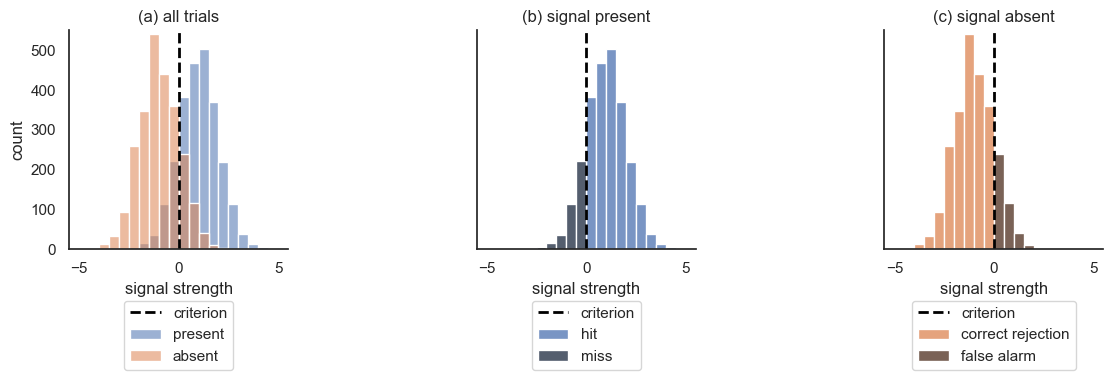

In [64]:
colors = sns.color_palette("deep", 2)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# All trials
sns.histplot(internal_signal[trial_type], bins=histogram_bins, color=colors[0], alpha=0.55, edgecolor="white", ax=axes[0], label="present")
sns.histplot(internal_signal[~trial_type], bins=histogram_bins, color=colors[1], alpha=0.55, edgecolor="white", ax=axes[0], label="absent")
axes[0].axvline(criterion, color="black", linestyle="--", linewidth=2, label="criterion")
axes[0].set(title="(a) all trials", xlabel="signal strength", ylabel="count")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=1)

# Signal-present trials
sns.histplot(internal_signal[trial_type & response], bins=histogram_bins, color=colors[0], alpha=0.75, edgecolor="white", ax=axes[1], label="hit")
sns.histplot(internal_signal[trial_type & ~response], bins=histogram_bins, color=np.array(colors[0]) * 0.35, alpha=0.75, edgecolor="white", ax=axes[1], label="miss")
axes[1].axvline(criterion, color="black", linestyle="--", linewidth=2, label="criterion")
axes[1].set(title="(b) signal present", xlabel="signal strength")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=1)

# Signal-absent trials
sns.histplot(internal_signal[~trial_type & ~response], bins=histogram_bins, color=colors[1], alpha=0.75, edgecolor="white", ax=axes[2], label="correct rejection")
sns.histplot(internal_signal[~trial_type & response], bins=histogram_bins, color=np.array(colors[1]) * 0.35, alpha=0.75, edgecolor="white", ax=axes[2], label="false alarm")
axes[2].axvline(criterion, color="black", linestyle="--", linewidth=2, label="criterion")
axes[2].set(title="(c) signal absent", xlabel="signal strength")
axes[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=1)

for ax in axes:
    ax.set_ylim(0, histogram_max)
    ax.set_box_aspect(1)
    sns.despine(ax=ax)
plt.tight_layout()

#### Count Occurrences of Each Possible Outcome

We now have a visual sense of how many hits, misses, false alarms, and correct rejections are in our simulated data, but let's count them to get more precise.

In [65]:
n_hit = np.sum(response[trial_type])
n_miss = np.sum(~response[trial_type])
n_false_alarm = np.sum(response[~trial_type])
n_correct_reject = np.sum(~response[~trial_type])

outcome_counts = pd.DataFrame(
    [[n_hit, n_miss], [n_false_alarm, n_correct_reject]],
    index=["signal present", "signal absent"],
    columns=["detected", "not detected"],
)
outcome_counts

,detected,not detected
signal present,2109,391
signal absent,410,2090


#### Calculate Rates of Each Possible Outcome

Now we know how many trials fall into the two halves of our signal-present and signal-absent histograms, but what proportion of each histogram is on the left vs. right side of the criterion?

In [66]:
hit_rate = n_hit / n_present
miss_rate = n_miss / n_present
false_alarm_rate = n_false_alarm / n_absent
correct_reject_rate = n_correct_reject / n_absent

outcome_rates = pd.DataFrame(
    [[hit_rate, miss_rate], [false_alarm_rate, correct_reject_rate]],
    index=["signal present", "signal absent"],
    columns=["detected", "not detected"],
)
outcome_rates

,detected,not detected
signal present,0.8436,0.1564
signal absent,0.1640,0.8360


These numbers tell us the area under either the signal-present or signal-absent curve occupied by each outcome. Importantly, these **area under the curve (AUC)** values can be used to determine **z-scores**. Essentially, a z-score tells you how many standard deviations above or below the mean that a particular value is. Usually means and standard deviations are used to find z-scores, but luckily for us, we can obtain a z-score with just the area under the curve (no knowledge of mean or standard deviation required!). (We'll get to why this is important very soon...)

As a concrete example, let's say that 84% of signal-present trials were hits (i.e., AUC = 0.84). That percentile corresponds to a z-score of 1. Thus, z(Hits) = 1. This indicates that the criterion value (which splits the signal-present distribution into hits and misses) is 1 standard deviation away from the mean of the signal-present distribution.

<br><br>
<img src="./photos/auc_signal_strength.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">

### Step 2. Calculate observer's sensitivity
- Now that we've evaluated our observer's performance on our signal detection task, we can work on evaluating their sensitivity to the signal (i.e., how detectable the signal was from the observer's perspective).

- To measure an observer's sensitivity independent of their decision criterion, we need to calculate **d'** (aka d-prime). d' is the difference in the means of the signal and noise distributions (i.e., the signal-present and signal-absent distributions) divided by their standard deviation (i.e., width, variability).

<br><br>
<img src="./photos/cohen_dprime.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">
<br><br>

**What does this equation accomplish?** The numerator takes the difference in the distributions' central locations into account, quantifying how far apart they are on the scale of signal perception strength. The denominator takes the distributions' spread into account, quantifying how concentrated the distributions are around their central locations.

Put simply, **<u>d' = separation / spread.</u>**

#### Check your understanding
Consider the following three examples. From the first (top) to the second (middle), only the mean of the noise distribution (gray) changes. From the second (middle) to the third (bottom), only the variability (width) of the distributions changes. **How do these changes affect d'?**

<br><br>
<img src="./photos/see_signal.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">
<br><br>

**... Ready to check your understanding? ...**


**Okay, so how do these changes affect d'?**
- From the first example to the second, the distance between the means increases. Thus, the numerator increases, and d' will be larger.
- From the second example to the third, the variability increases. Thus, the denominator increases, and d' will be smaller.

#### How can trial outcomes be used to calculate d'?
Now you know how to calculate d' when we know the means and standard deviations of the signal and noise distributions, but the crux of the problem is that we don't know what those values are in a real experiment. Rather, for each trial, we know the condition (signal present vs. absent), how the observer responded, and thus whether the trial was a hit, miss, false alarm, or correct rejection. This begs the question, **how do we calculate d-prime with just hits, misses, false alarms, and correct rejections?**

The answer to that question involves z-scores. As we covered above, a z-score tells you how many standard deviations above or below the mean that a particular value is, and importantly for this case, z-scores are related to the area under a curve.

We've already looked at an example showing **<u>z(Hits)</u>**. Recall that z(Hits) represents the distance (in units of standard deviation) between the criterion value and the mean of the **<u>signal-present</u>** distribution.

Similarly, **<u>-z(False Alarms)</u>** represents the distance (in units of standard deviation) between the criterion value and the mean of the **<u>signal-absent</u>** distribution. (Note: We use the negative false alarm z-score here because the criterion is on the opposite side of this distribution. Specifically, the criterion is to the left of the signal-present distribution but to the right of the signal-absent distribution.)

Therefore, the distance between the mean of the signal-present distribution and the mean of the signal-absent distribution (in units of standard deviation) is equal to the sum of z(Hits) and -z(False Alarms). And what variable represents the distance between these distributions, normalized by the standard deviation? **<u>d'</u>**! Thus, **d' = z(Hits) - z(False Alarms)**.

<br><br>
<img src="./photos/zhit_falsealarms.png" alt="signal detection histogram" width="500" style="display:block; margin-left:auto; margin-right:auto;">
<br><br>

(FYI: In some places, you may instead see d' = z(False Alarms) - z(Hits). Which equation is "right" vs. "wrong" depends on whether left- or right-tailed z-scores are used. That distinction is worth paying attention to if you're ever setting up these calculations yourself, but for this lab, you can forget all about it.)

#### Use trial outcomes to calculate d'
Now that we know **<u>d' = z(Hits) - z(False Alarms)</u>**, let's find Turtle's d'!

We first need to calculate z-scores for our hit and false alarm rates. These rates correspond to specific areas underneath Gaussian probability density functions (AUC values). Given a particular z-score, we can use the cumulative density function (CDF) of a normalized Gaussian distribution (i.e., a normal distribution with a mean of 0 and standard deviation of 1) to find the corresponding AUC. Thus, given a particular AUC, we can use the inverse CDF of a normalized Gaussian to find the corresponding z-score.

Once we get the two z-scores we need, all we need to do is subtract them, and then we'll have the observer's d' value.

In [67]:
def z_from_rate(rate, n_trials=None):
    """Convert a response rate to a z-score, with finite-sample correction for 0/1 rates."""
    rate = float(rate)
    if n_trials is not None:
        if rate == 0:
            rate = 0.5 / n_trials
        elif rate == 1:
            rate = 1 - 0.5 / n_trials
    rate = min(max(rate, 1e-12), 1 - 1e-12)
    return normal.inv_cdf(rate)

z_hits = z_from_rate(hit_rate, n_present)
z_false_alarms = z_from_rate(false_alarm_rate, n_absent)
d_prime = z_hits - z_false_alarms

print("d' = z(H) - z(FA)")
print(f"{d_prime:.2f} = {z_hits:.2f} - {z_false_alarms:.2f}")

d' = z(H) - z(FA)
1.99 = 1.01 - -0.98


## Part C. Test the Impact of the Criterion Value

In trying to understand d', you may ask yourself: does d' depend on the decision criterion? In other words, is the d-prime measurement sensitive in any systematic way to changes in the criterion?

### Step 1. Determine What You Expect to Find

What would happen if Turtle increased their criterion and only reported detecting the signal when absolutely sure? What if instead Turtle tried to minimize misses by lowering their criterion? Try thinking through the impact of both changes on hit rate, false alarm rate, and d'.

#### Plot the Signal and Noise Distributions With Different Criterion Values
Since visuals are often helpful, let's plot Turtle's signal-present and signal-absent distributions again, and let's plot several different criterion values.


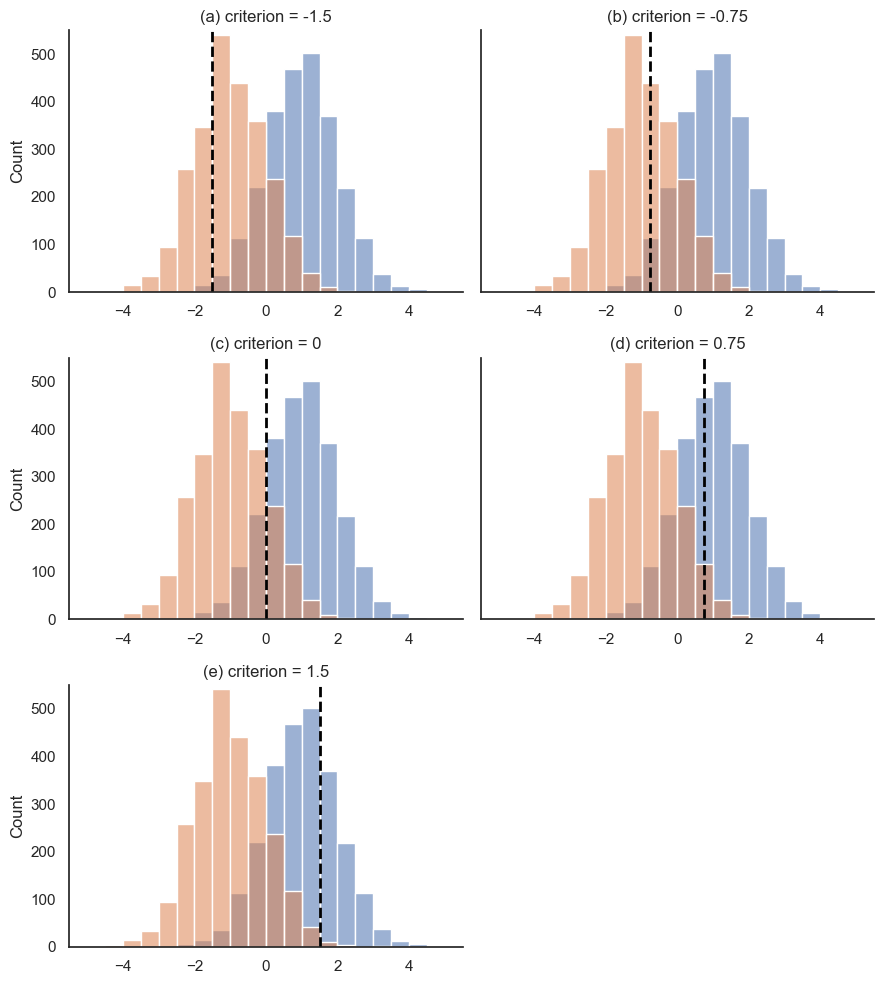

In [68]:
changing_criterion = np.arange(-1.5, 1.5 + 0.75, 0.75)
n_criteria = len(changing_criterion)

fig, axes = plt.subplots(3, 2, figsize=(9, 10), sharex=True, sharey=True)
axes = axes.ravel()
for cc, crit in enumerate(changing_criterion):
    ax = axes[cc]
    sns.histplot(internal_signal[trial_type], bins=histogram_bins, color=colors[0], alpha=0.55, edgecolor="white", ax=ax, label="present")
    sns.histplot(internal_signal[~trial_type], bins=histogram_bins, color=colors[1], alpha=0.55, edgecolor="white", ax=ax, label="absent")
    ax.axvline(crit, color="black", linestyle="--", linewidth=2)
    ax.set_title(f"({chr(97 + cc)}) criterion = {crit:g}")
    ax.set_ylim(0, histogram_max)
    sns.despine(ax=ax)

for ax in axes:
    ax.tick_params(axis='x', labelbottom=True)

for ax in axes[n_criteria:]:
    ax.axis("off")
plt.tight_layout()

Learning check: Can you identify which areas in each subplot correspond to each of our four possible trial outcomes: hits, misses, false alarms, and correct rejections?

### Step 2. Move the Criterion and Analyze the Results

Now that you've developed some ideas about what you expect to find, let's repeat the calculations we did above for several different decision criteria.

In [69]:
changing_criterion = np.arange(-1.5, 1.5 + 0.75, 0.75)
n_criteria = len(changing_criterion)

cc_hit_rate = np.empty(n_criteria)
cc_fa_rate = np.empty(n_criteria)
cc_d_prime = np.empty(n_criteria)

for cc, crit in enumerate(changing_criterion):
    these_responses = internal_signal >= crit
    cc_hit_rate[cc] = np.sum(these_responses[trial_type]) / n_present
    cc_fa_rate[cc] = np.sum(these_responses[~trial_type]) / n_absent
    cc_d_prime[cc] = z_from_rate(cc_hit_rate[cc], n_present) - z_from_rate(cc_fa_rate[cc], n_absent)

criterion_df = pd.DataFrame({
    "criterion": changing_criterion,
    "hit_rate": cc_hit_rate,
    "false_alarm_rate": cc_fa_rate,
    "d_prime": cc_d_prime,
})
criterion_df

,criterion,hit_rate,false_alarm_rate,d_prime
0,-1.50,0.9916,0.7000,1.866655
1,-0.75,0.9604,0.3820,2.055579
2,0.00,0.8436,0.1640,1.987514
3,0.75,0.6048,0.0396,2.021138
4,1.50,0.3032,0.0056,2.021177


#### What Is the Criterion's Impact on Hit and False Alarm Rates?

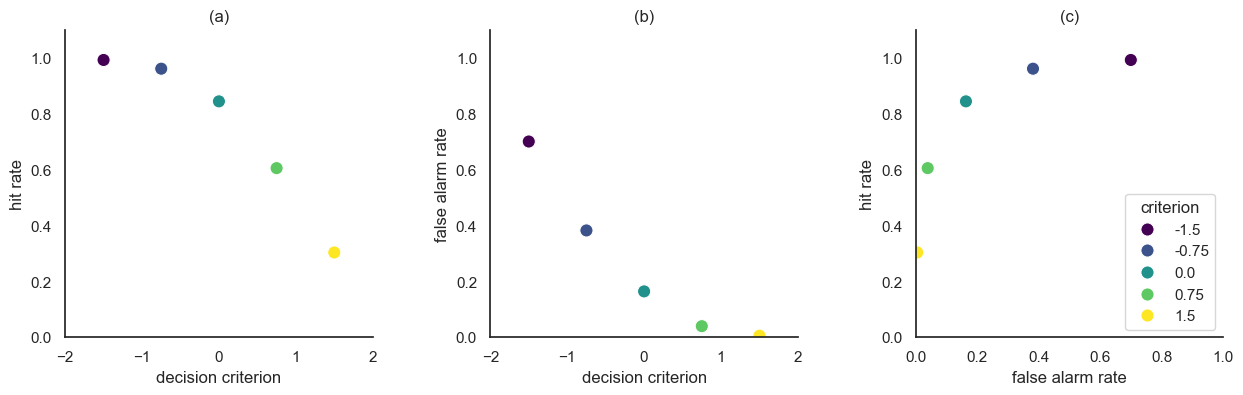

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.scatterplot(data=criterion_df, x="criterion", y="hit_rate", hue="criterion", palette="viridis", s=90, legend=False, ax=axes[0])
axes[0].set(title="(a)", xlabel="decision criterion", ylabel="hit rate", xlim=(-2, 2), ylim=(0, 1.1))

sns.scatterplot(data=criterion_df, x="criterion", y="false_alarm_rate", hue="criterion", palette="viridis", s=90, legend=False, ax=axes[1])
axes[1].set(title="(b)", xlabel="decision criterion", ylabel="false alarm rate", xlim=(-2, 2), ylim=(0, 1.1))

sns.scatterplot(data=criterion_df, x="false_alarm_rate", y="hit_rate", hue="criterion", palette="viridis", s=90, ax=axes[2])
axes[2].set(title="(c)", xlabel="false alarm rate", ylabel="hit rate", xlim=(0, 1), ylim=(0, 1.1))
axes[2].legend(title="criterion", loc="lower right")

for ax in axes:
    ax.set_box_aspect(1)
    sns.despine(ax=ax)
plt.tight_layout()

Notice anything interesting? Anything unexpected?

#### What Is the Criterion's Impact on d'?

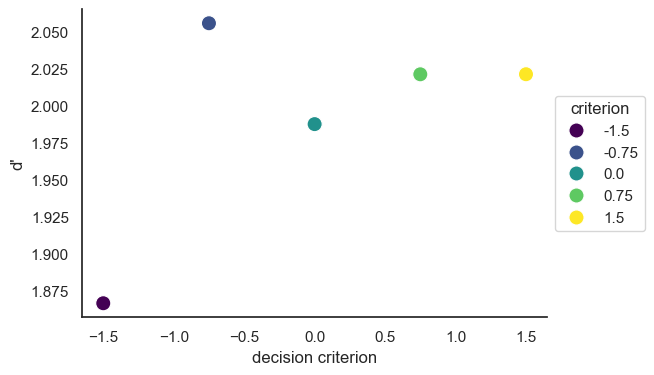

In [71]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=criterion_df, x="criterion", y="d_prime", hue="criterion", palette="viridis", s=120, ax=ax)
ax.set(xlabel="decision criterion", ylabel="d'")
ax.legend(title="criterion", loc="center left", bbox_to_anchor=(1, 0.5))
sns.despine(ax=ax)

What do you think? Is there a systematic relationship?

### Step 3. Increase Your Sample Size

Drawing conclusions from a small sample size has led many researchers astray, so let's repeat our tests for lots more criterion values.

In [72]:
changing_criterion = np.round(np.arange(-1.5, 1.5 + 0.1, 0.1), 10)
n_criteria = len(changing_criterion)

cc_hit_rate = np.empty(n_criteria)
cc_fa_rate = np.empty(n_criteria)
cc_d_prime = np.empty(n_criteria)

for cc, crit in enumerate(changing_criterion):
    these_responses = internal_signal >= crit
    cc_hit_rate[cc] = np.sum(these_responses[trial_type]) / n_present
    cc_fa_rate[cc] = np.sum(these_responses[~trial_type]) / n_absent
    cc_d_prime[cc] = z_from_rate(cc_hit_rate[cc], n_present) - z_from_rate(cc_fa_rate[cc], n_absent)

criterion_dense_df = pd.DataFrame({
    "criterion": changing_criterion,
    "hit_rate": cc_hit_rate,
    "false_alarm_rate": cc_fa_rate,
    "d_prime": cc_d_prime,
})

#### What Is the Criterion's Impact on d'?

Let's switch things up and start by plotting d' this go-round.

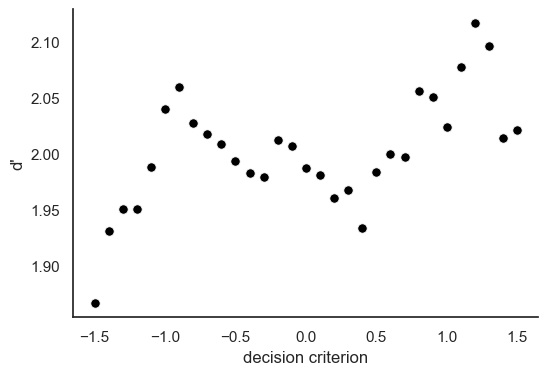

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=criterion_dense_df, x="criterion", y="d_prime", color="black", s=45, ax=ax)
ax.set(xlabel="decision criterion", ylabel="d'")
sns.despine(ax=ax)

Do the additional data points change your opinion? What's your final verdict? Is there a systematic relationship between an observer's decision criterion and d'?

#### What Is the Criterion's Impact on Hit and False Alarm Rates?

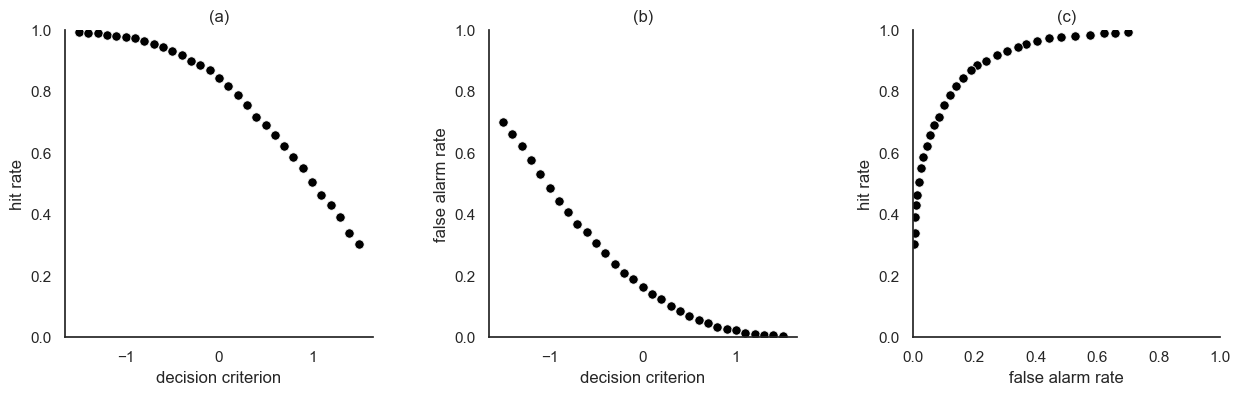

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.scatterplot(data=criterion_dense_df, x="criterion", y="hit_rate", color="black", s=45, ax=axes[0])
axes[0].set(title="(a)", xlabel="decision criterion", ylabel="hit rate", ylim=(0, 1))

sns.scatterplot(data=criterion_dense_df, x="criterion", y="false_alarm_rate", color="black", s=45, ax=axes[1])
axes[1].set(title="(b)", xlabel="decision criterion", ylabel="false alarm rate", ylim=(0, 1))

sns.scatterplot(data=criterion_dense_df, x="false_alarm_rate", y="hit_rate", color="black", s=45, ax=axes[2])
axes[2].set(title="(c)", xlabel="false alarm rate", ylabel="hit rate", xlim=(0, 1), ylim=(0, 1))

for ax in axes:
    ax.set_box_aspect(1)
    sns.despine(ax=ax)
plt.tight_layout()

Do the additional data points change your opinion about these relationships? What's your final verdict about whether there are systematic relationships between these values?

## Part D. Test the Impact of d'

Because we're simulating this experiment, we can control the properties of our observer's signal and noise distributions, thereby controlling d'. To confirm this, let's try changing the mean of our observer's noise distribution.

In [75]:
changing_mean = np.arange(1, -2 - 0.5, -0.5)
n_means = len(changing_mean)

cmu_true_d_prime = (dist_mean_present - changing_mean) / dist_stdev

changing_criterion = np.round(np.arange(-2, 2 + 0.1, 0.1), 10)
n_criteria = len(changing_criterion)

cmu_internal_signal = np.empty((n_trials, n_means))
cmu_hit_rate = np.empty((n_criteria, n_means))
cmu_fa_rate = np.empty((n_criteria, n_means))
cmu_d_prime = np.empty((n_criteria, n_means))

for mm, noise_mean in enumerate(changing_mean):
    cmu_internal_signal[trial_type, mm] = rng.normal(dist_mean_present, dist_stdev, size=n_present)
    cmu_internal_signal[~trial_type, mm] = rng.normal(noise_mean, dist_stdev, size=n_absent)

    for cc, crit in enumerate(changing_criterion):
        these_responses = cmu_internal_signal[:, mm] >= crit
        cmu_hit_rate[cc, mm] = np.sum(these_responses[trial_type]) / n_present
        cmu_fa_rate[cc, mm] = np.sum(these_responses[~trial_type]) / n_absent
        cmu_d_prime[cc, mm] = z_from_rate(cmu_hit_rate[cc, mm], n_present) - z_from_rate(cmu_fa_rate[cc, mm], n_absent)

### Step 1. Compare "True" and Simulated d' Values

First, let's make sure that the d' values we calculated from our simulations match up with what they should be, based on the distribution parameters that we defined.

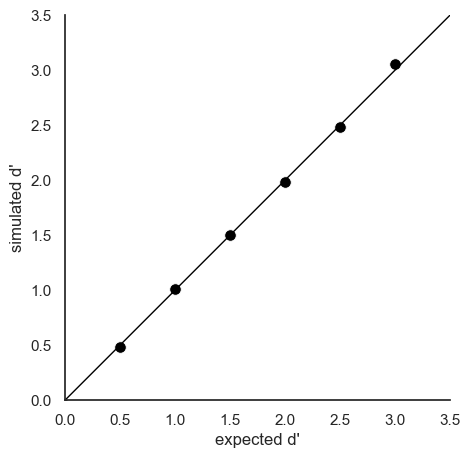

In [76]:
true_vs_simulated_df = pd.DataFrame({
    "expected_d_prime": cmu_true_d_prime,
    "simulated_d_prime": np.median(cmu_d_prime, axis=0),
})

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=true_vs_simulated_df, x="expected_d_prime", y="simulated_d_prime", color="black", s=70, ax=ax)
ax.plot([0, 3.5], [0, 3.5], color="black", linewidth=1)
ax.set(xlabel="expected d'", ylabel="simulated d'", xlim=(0, 3.5), ylim=(0, 3.5))
ax.set_box_aspect(1)
sns.despine(ax=ax)

### Step 2. Compare Hit and False Alarm Rates

Hit and false alarm rates are important values in signal detection theory, so let's see how changing d' impacts the relationship between hit rate (true positive rate) and false alarm rate (false positive rate).

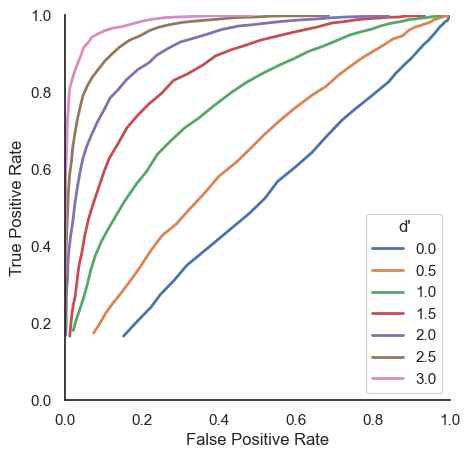

In [78]:
roc_rows = []
for mm, d_val in enumerate(cmu_true_d_prime):
    for cc, crit in enumerate(changing_criterion):
        roc_rows.append({
            "expected_d_prime": f"{d_val:.1f}",
            "criterion": crit,
            "false_positive_rate": cmu_fa_rate[cc, mm],
            "true_positive_rate": cmu_hit_rate[cc, mm],
        })
roc_df = pd.DataFrame(roc_rows)

fig, ax = plt.subplots(figsize=(6, 5))
sns.lineplot(data=roc_df, x="false_positive_rate", y="true_positive_rate", hue="expected_d_prime", linewidth=2, ax=ax)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", xlim=(0, 1), ylim=(0, 1))
ax.legend(title="d'", loc="lower right")
ax.set_box_aspect(1)
sns.despine(ax=ax)

The curves you've just plotted are called **receiver operating characteristic (ROC) curves**. You draw one by plotting the false positive rate vs. the true positive rate as a function of the decision criterion. In other words, you generate an ROC curve by changing the decision criterion.

What do you notice about the relationship between d' and the ROC curve?